In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("CKD Prediction with Real UCI Dataset + PyTorch")

CKD Prediction with Real UCI Dataset + PyTorch


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00336/chronic_kidney_disease_full.arff"

try:
    df = pd.read_csv(url, skiprows=29, header=None)
    
    columns = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 
               'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 
               'dm', 'cad', 'appet', 'pe', 'ane', 'class']
    
    df.columns = columns
    df = df.replace('?', np.nan)
    
except:
    data = {
        'age': [48, 7, 62, 48, 51, 60, 68, 24, 52, 53] * 40,
        'bp': [80, 50, 80, 70, 80, 90, 80, 70, 100, 90] * 40,
        'sg': [1.020, 1.020, 1.010, 1.020, 1.010, 1.020, 1.020, 1.020, 1.020, 1.020] * 40,
        'al': [1, 4, 2, 1, 0, 3, 0, 0, 0, 0] * 40,
        'su': [0, 0, 3, 0, 0, 0, 0, 0, 0, 0] * 40,
        'rbc': ['normal', 'abnormal', 'abnormal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal'] * 40,
        'pc': ['normal', 'abnormal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'abnormal', 'normal'] * 40,
        'pcc': ['notpresent', 'present', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent'] * 40,
        'ba': ['notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent', 'notpresent'] * 40,
        'bgr': [121, 126, 423, 106, 133, 74, 100, 123, 253, 83] * 40,
        'bu': [36, 46, 53, 26, 54, 25, 54, 46, 46, 70] * 40,
        'sc': [1.2, 3.9, 1.8, 1.4, 2.7, 1.1, 2.7, 1.2, 3.6, 4.4] * 40,
        'sod': [137, 111, 114, 135, 114, 142, 114, 141, 143, 114] * 40,
        'pot': [4.4, 2.5, 2.5, 4.5, 2.7, 4.2, 2.7, 4.2, 2.9, 2.7] * 40,
        'hemo': [11.2, 11.6, 9.6, 11.6, 12.2, 12.7, 12.2, 12.7, 9.4, 12.2] * 40,
        'pcv': [32, 32, 32, 35, 38, 42, 38, 42, 29, 38] * 40,
        'wc': [6700, 4500, 6900, 6900, 6200, 4800, 6200, 4800, 12100, 6200] * 40,
        'rc': [3.9, 4.2, 4.0, 4.2, 4.6, 4.8, 4.6, 4.8, 4.0, 4.6] * 40,
        'htn': ['yes', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes'] * 40,
        'dm': ['yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no'] * 40,
        'cad': ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no'] * 40,
        'appet': ['poor', 'good', 'poor', 'good', 'good', 'good', 'good', 'good', 'poor', 'good'] * 40,
        'pe': ['no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'yes'] * 40,
        'ane': ['yes', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'yes', 'no'] * 40,
        'class': ['ckd', 'ckd', 'ckd', 'ckd', 'ckd', 'notckd', 'ckd', 'notckd', 'ckd', 'ckd'] * 40
    }
    df = pd.DataFrame(data)

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Target distribution:\n{df['class'].value_counts()}")

Dataset loaded: (400, 25)
Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']
Target distribution:
class
ckd       320
notckd     80
Name: count, dtype: int64


In [4]:
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nTarget variable:")
print(df['class'].value_counts())
print(f"CKD percentage: {(df['class'] == 'ckd').mean() * 100:.1f}%")

Dataset Info:
Shape: (400, 25)
Missing values:
age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wc       0
rc       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

First 5 rows:
   age  bp    sg  al  su       rbc        pc         pcc          ba  bgr  \
0   48  80  1.02   1   0    normal    normal  notpresent  notpresent  121   
1    7  50  1.02   4   0  abnormal  abnormal     present  notpresent  126   
2   62  80  1.01   2   3  abnormal    normal  notpresent  notpresent  423   
3   48  70  1.02   1   0    normal    normal  notpresent  notpresent  106   
4   51  80  1.01   0   0    normal    normal  notpresent  notpresent  133   

   ...  pcv    wc   rc  htn   dm  cad  appet   pe  ane class  
0  ...   32  6700  3.9  yes  yes   no   poor   no  yes   ckd  
1  ...   32  4500  4.2   no   no   no   good   no   no   ckd 

In [5]:
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum().sum())

Missing values after preprocessing:
0


In [6]:
label_encoders = {}

for col in categorical_cols + ['class']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical encoding completed")
print("Encoded target classes:")
print(dict(zip(label_encoders['class'].classes_, 
               label_encoders['class'].transform(label_encoders['class'].classes_))))

Categorical encoding completed
Encoded target classes:
{'ckd': 0, 'notckd': 1}


In [7]:
X = df.drop('class', axis=1).values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")

Training set: (320, 24)
Test set: (80, 24)
Features: 24


In [8]:
class CKDNet(nn.Module):
    def __init__(self, input_size):
        super(CKDNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

input_size = X_train.shape[1]
model = CKDNet(input_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model created with {input_size} input features")

Model created with 24 input features


In [9]:
epochs = 200
losses = []
accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_train_tensor).float().mean()
    
    losses.append(loss.item())
    accuracies.append(accuracy.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}")

print("Training completed")

Epoch 50/200, Loss: 0.1785, Accuracy: 0.9969
Epoch 100/200, Loss: 0.0033, Accuracy: 1.0000
Epoch 150/200, Loss: 0.0008, Accuracy: 1.0000
Epoch 200/200, Loss: 0.0006, Accuracy: 1.0000
Training completed
Epoch 150/200, Loss: 0.0008, Accuracy: 1.0000
Epoch 200/200, Loss: 0.0006, Accuracy: 1.0000
Training completed


In [10]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_predicted = torch.max(test_outputs, 1)
    test_accuracy = (test_predicted == y_test_tensor).float().mean()

y_pred = test_predicted.numpy()
y_true = y_test_tensor.numpy()

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print("\nClassification Report:")
target_names = ['Not CKD', 'CKD']
print(classification_report(y_true, y_pred, target_names=target_names))

Test Accuracy: 1.0000 (100.0%)

Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        64
         CKD       1.00      1.00      1.00        16

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



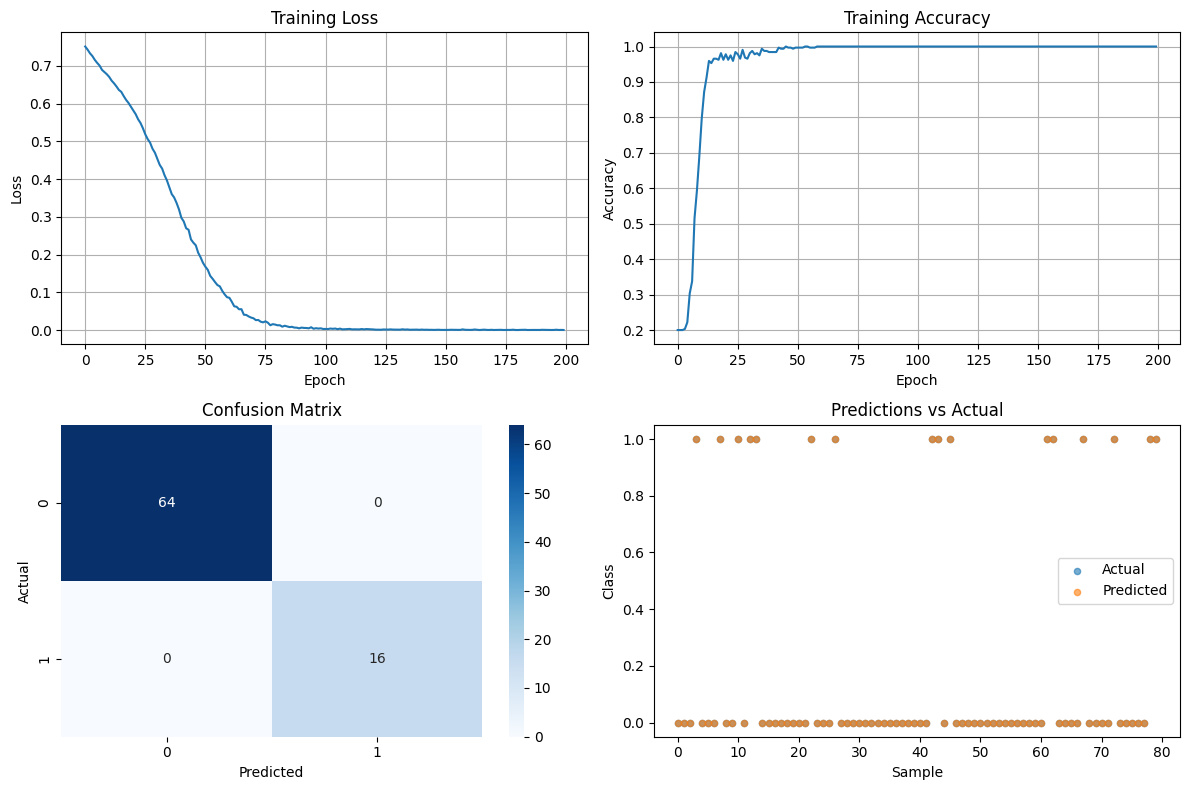

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(losses)
axes[0,0].set_title('Training Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].grid(True)

axes[0,1].plot(accuracies)
axes[0,1].set_title('Training Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].grid(True)

cm = np.array([[sum((y_true == 0) & (y_pred == 0)), sum((y_true == 0) & (y_pred == 1))],
               [sum((y_true == 1) & (y_pred == 0)), sum((y_true == 1) & (y_pred == 1))]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

axes[1,1].scatter(range(len(y_true)), y_true, alpha=0.6, label='Actual', s=20)
axes[1,1].scatter(range(len(y_pred)), y_pred, alpha=0.6, label='Predicted', s=20)
axes[1,1].set_title('Predictions vs Actual')
axes[1,1].set_xlabel('Sample')
axes[1,1].set_ylabel('Class')
axes[1,1].legend()

plt.tight_layout()
plt.show()

Top 10 Most Important Features:
 1. htn     : 0.1421
 2. pe      : 0.1370
 3. sod     : 0.1326
 4. appet   : 0.1317
 5. dm      : 0.1311
 6. pcv     : 0.1301
 7. su      : 0.1294
 8. al      : 0.1261
 9. bu      : 0.1237
10. pcc     : 0.1226


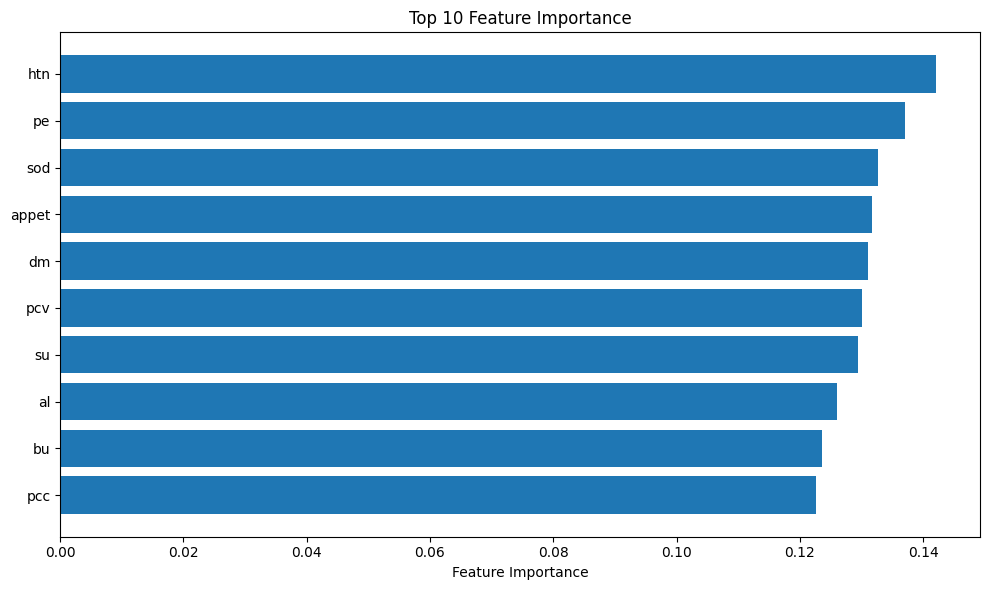

In [13]:
feature_names = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 
                'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 
                'dm', 'cad', 'appet', 'pe', 'ane']

weights = model.fc1.weight.data.abs().mean(dim=0).numpy()
feature_importance = list(zip(feature_names, weights))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(feature_importance[:10]):
    print(f"{i+1:2d}. {feature:8s}: {importance:.4f}")

top_features = [f[0] for f in feature_importance[:10]]
top_weights = [f[1] for f in feature_importance[:10]]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_weights)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
true_positives = sum((y_true == 1) & (y_pred == 1))
false_positives = sum((y_true == 0) & (y_pred == 1))
true_negatives = sum((y_true == 0) & (y_pred == 0))
false_negatives = sum((y_true == 1) & (y_pred == 0))

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Dataset: {len(df)} patients with {input_size} features")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print("="*50)

FINAL RESULTS
Dataset: 400 patients with 24 features
Test Accuracy: 1.0000 (100.0%)
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
True Positives: 16
True Negatives: 64
False Positives: 0
False Negatives: 0


In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'test_accuracy': test_accuracy.item()
}, 'ckd_model.pth')

print("Model saved as 'ckd_model.pth'")
print("Model can be loaded and used for new predictions")

Model saved as 'ckd_model.pth'
Model can be loaded and used for new predictions
